In [6]:
# Basic Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

# Settings
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

<Figure size 800x500 with 0 Axes>

In [7]:
cols = [
    "Severity",
    "Start_Time",
    "City",
    "State",
    "Temperature(F)",
    "Visibility(mi)",
    "Weather_Condition",
    "Sunrise_Sunset",
    "Start_Lat",
    "Start_Lng"
]

df = pd.read_csv(
    "US_Accidents_March23.csv",
    usecols=cols,
    nrows=1000000
)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1000000, 10)


,Severity,Start_Time,Start_Lat,Start_Lng,City,State,Temperature(F),Visibility(mi),Weather_Condition,Sunrise_Sunset
0,3,2016-02-08 05:46:00,39.865147,-84.058723,Dayton,OH,36.9,10.0,Light Rain,Night
1,2,2016-02-08 06:07:59,39.928059,-82.831184,Reynoldsburg,OH,37.9,10.0,Light Rain,Night
2,2,2016-02-08 06:49:27,39.063148,-84.032608,Williamsburg,OH,36.0,10.0,Overcast,Night
3,3,2016-02-08 07:23:34,39.747753,-84.205582,Dayton,OH,35.1,9.0,Mostly Cloudy,Night
4,2,2016-02-08 07:39:07,39.627781,-84.188354,Dayton,OH,36.0,6.0,Mostly Cloudy,Day


In [8]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (1000000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Severity           1000000 non-null  int64  
 1   Start_Time         1000000 non-null  object 
 2   Start_Lat          1000000 non-null  float64
 3   Start_Lng          1000000 non-null  float64
 4   City               999972 non-null   object 
 5   State              1000000 non-null  object 
 6   Temperature(F)     984702 non-null   float64
 7   Visibility(mi)     981069 non-null   float64
 8   Weather_Condition  981789 non-null   object 
 9   Sunrise_Sunset     998364 non-null   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 76.3+ MB


In [9]:
df.isnull().sum().sort_values(ascending=False).head(20)

Visibility(mi)       18931
Weather_Condition    18211
Temperature(F)       15298
Sunrise_Sunset        1636
City                    28
Severity                 0
Start_Time               0
State                    0
Start_Lat                0
Start_Lng                0
dtype: int64

In [10]:
df["Weather_Condition"].fillna("Unknown", inplace=True)
df["Visibility(mi)"].fillna(df["Visibility(mi)"].median(), inplace=True)
df["Temperature(F)"].fillna(df["Temperature(F)"].median(), inplace=True)
df["Sunrise_Sunset"].fillna("Day", inplace=True)

C:\Users\akshi\AppData\Local\Temp\ipykernel_3096\728787140.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Weather_Condition"].fillna("Unknown", inplace=True)
C:\Users\akshi\AppData\Local\Temp\ipykernel_3096\728787140.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

In [11]:
df.drop_duplicates(inplace=True)
print("New Shape:", df.shape)

New Shape: (997629, 10)


In [12]:
df["Start_Time"] = pd.to_datetime(df["Start_Time"])
df["Hour"] = df["Start_Time"].dt.hour
df["Day"] = df["Start_Time"].dt.dayofweek

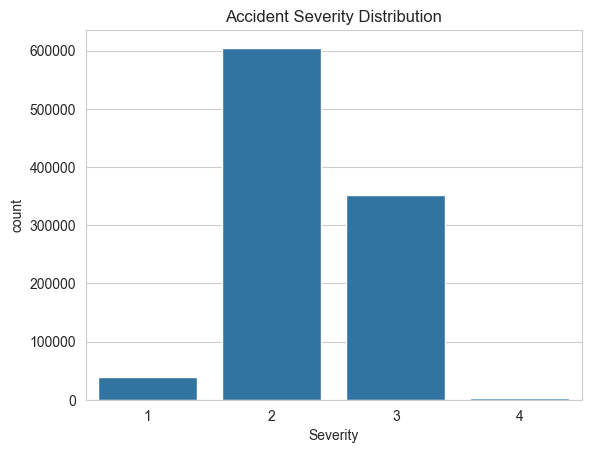

In [13]:
sns.countplot(x="Severity", data=df)
plt.title("Accident Severity Distribution")
plt.show()

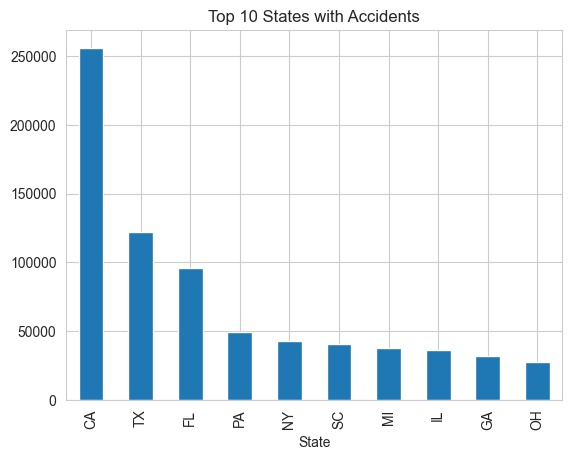

In [14]:
df["State"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 States with Accidents")
plt.show()

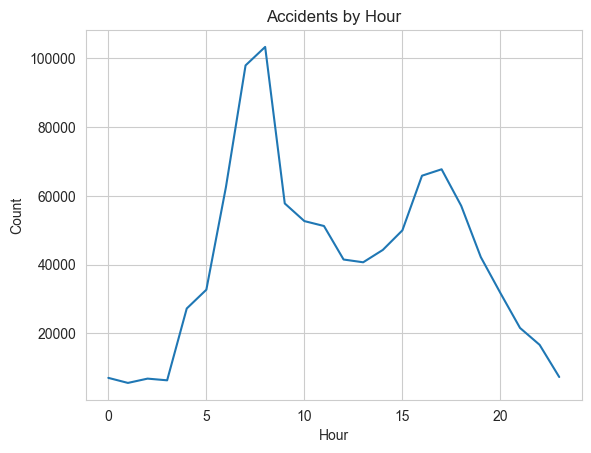

In [15]:
df["Hour"].value_counts().sort_index().plot()
plt.title("Accidents by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

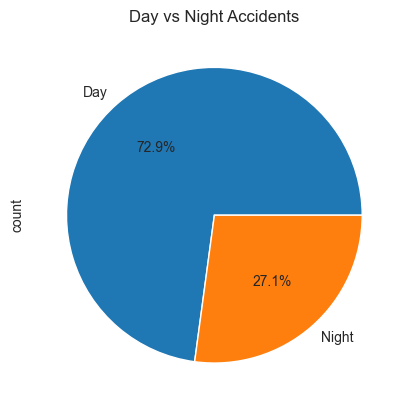

In [16]:
df["Sunrise_Sunset"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Day vs Night Accidents")
plt.show()

In [17]:
features = df[[
    "Severity",
    "Temperature(F)",
    "Visibility(mi)",
    "Hour"
]].copy()

In [18]:
Q1 = features.quantile(0.25)
Q3 = features.quantile(0.75)
IQR = Q3 - Q1

features = features[~((features < (Q1 - 1.5 * IQR)) | 
                      (features > (Q3 + 1.5 * IQR))).any(axis=1)]

In [19]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

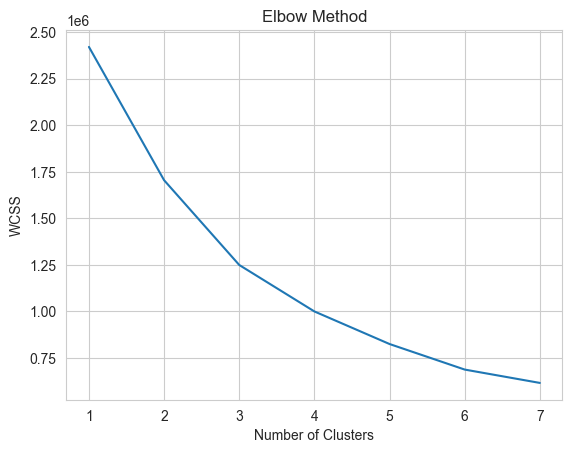

In [20]:
wcss = []

for i in range(1, 8):
    kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,8), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [21]:
kmeans = KMeans(n_clusters=3, init="k-means++", random_state=42)
clusters = kmeans.fit_predict(scaled_data)

features["KMeans_Cluster"] = clusters

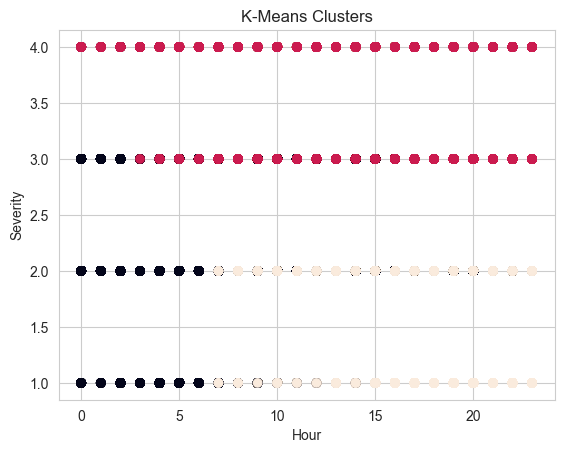

In [22]:
plt.scatter(features["Hour"], features["Severity"], c=features["KMeans_Cluster"])
plt.xlabel("Hour")
plt.ylabel("Severity")
plt.title("K-Means Clusters")
plt.show()

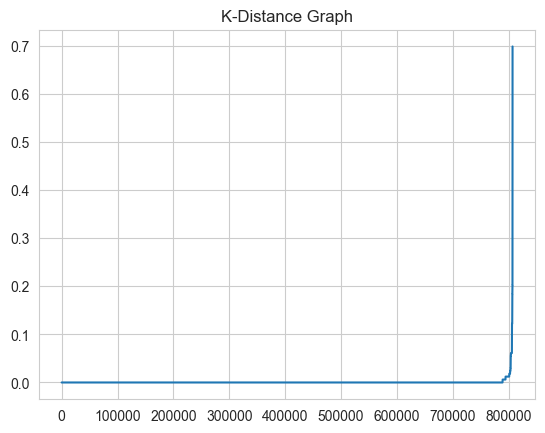

In [23]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(scaled_data)
distances, indices = neighbors_fit.kneighbors(scaled_data)

distances = np.sort(distances[:,4])
plt.plot(distances)
plt.title("K-Distance Graph")
plt.show()

In [27]:
# Convert to float32 (reduces memory usage)
scaled_data = scaled_data.astype(np.float32)

# Take random 20,000 sample
sample_indices = np.random.choice(len(scaled_data), 20000, replace=False)
dbscan_sample = scaled_data[sample_indices]

# Apply DBSCAN
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5,
    algorithm='ball_tree',   # Faster & memory efficient
    n_jobs=-1
)

db_clusters = dbscan.fit_predict(dbscan_sample)

print("Unique clusters:", set(db_clusters))

Unique clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(-1)}


In [28]:
features_sample = features.iloc[sample_indices].copy()
features_sample["DBSCAN_Cluster"] = db_clusters

In [29]:
features_sample["DBSCAN_Cluster"] = db_clusters
features_sample.head()

,Severity,Temperature(F),Visibility(mi),Hour,KMeans_Cluster,DBSCAN_Cluster
494378,3,71.1,10.0,7,1,0
986428,2,64.0,10.0,13,2,1
419760,2,59.0,10.0,19,2,1
860861,3,76.0,10.0,18,1,0
149903,2,55.0,10.0,15,2,1


In [30]:
features_sample["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
 1    11898
 0     7159
 2      864
 3       66
-1       13
Name: count, dtype: int64

In [31]:
noise_count = sum(features_sample["DBSCAN_Cluster"] == -1)
print("Number of Noise Points:", noise_count)

Number of Noise Points: 13


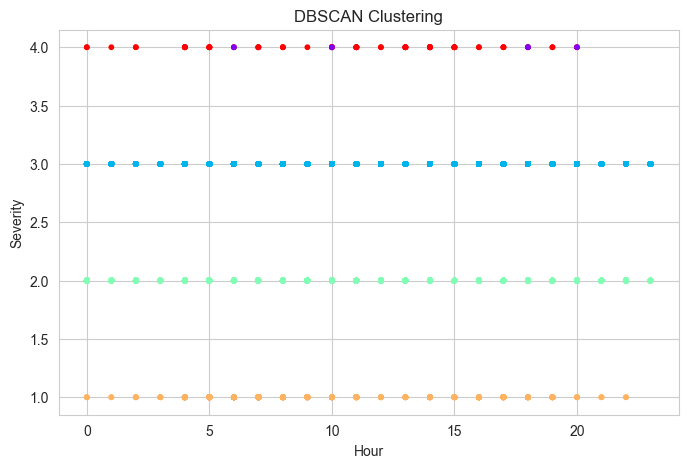

In [32]:
plt.figure(figsize=(8,5))
plt.scatter(
    features_sample["Hour"],
    features_sample["Severity"],
    c=features_sample["DBSCAN_Cluster"],
    cmap="rainbow",
    s=10
)
plt.xlabel("Hour")
plt.ylabel("Severity")
plt.title("DBSCAN Clustering")
plt.show()

In [33]:
print("KMeans Clusters:")
print(features["KMeans_Cluster"].value_counts())

KMeans Clusters:
KMeans_Cluster
2    304534
0    254152
1    248354
Name: count, dtype: int64


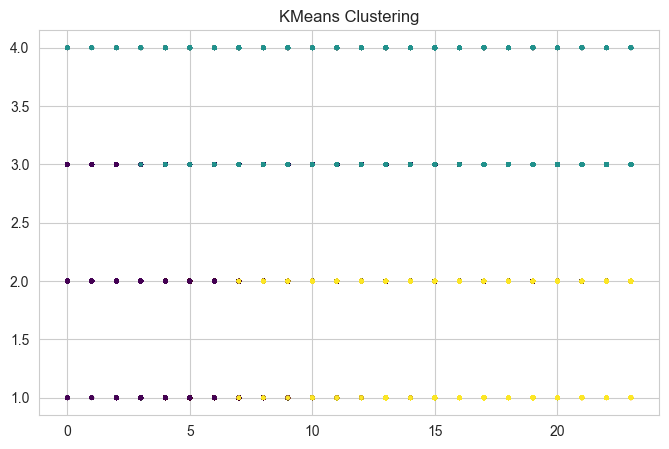

In [34]:
plt.figure(figsize=(8,5))
plt.scatter(
    features["Hour"],
    features["Severity"],
    c=features["KMeans_Cluster"],
    cmap="viridis",
    s=5
)
plt.title("KMeans Clustering")
plt.show()

In [36]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_data[:20000], features_sample["DBSCAN_Cluster"])
print("Silhouette Score (DBSCAN sample):", score)

Silhouette Score (DBSCAN sample): -0.02528279460966587


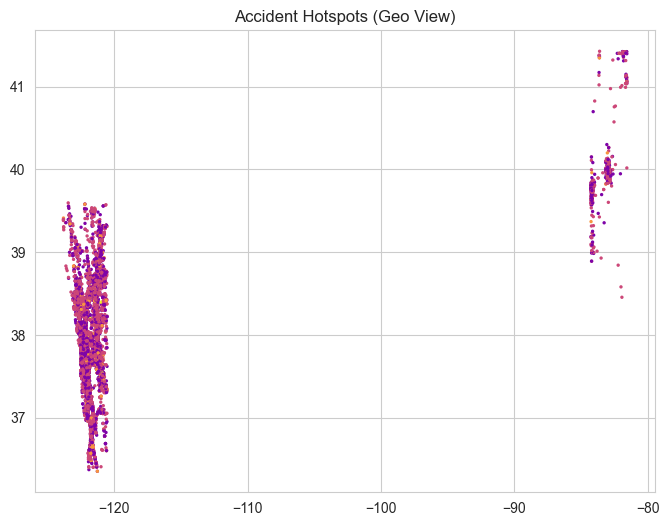

In [37]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["Start_Lng"][:20000],
    df["Start_Lat"][:20000],
    c=features_sample["DBSCAN_Cluster"],
    s=2,
    cmap="plasma"
)
plt.title("Accident Hotspots (Geo View)")
plt.show()